# 📊 Customer Churn Analysis
**Dataset:** `customer_churn_dataset-testing-master.csv`  
**Author:** Shoyemi Jonathan Showunmi  
**Rows:** 64,374 | **Features:** 12

This notebook covers:
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Preprocessing
4. Model Training (Logistic Regression + Random Forest)
5. Model Evaluation & Feature Importance

## 1. Imports & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(r'C:\Users\PSALMS COMPUTER\Desktop\customer_churn_dataset-testing-master.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


## 2. Data Inspection

In [5]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB

Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subsc

In [6]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## 3. Exploratory Data Analysis

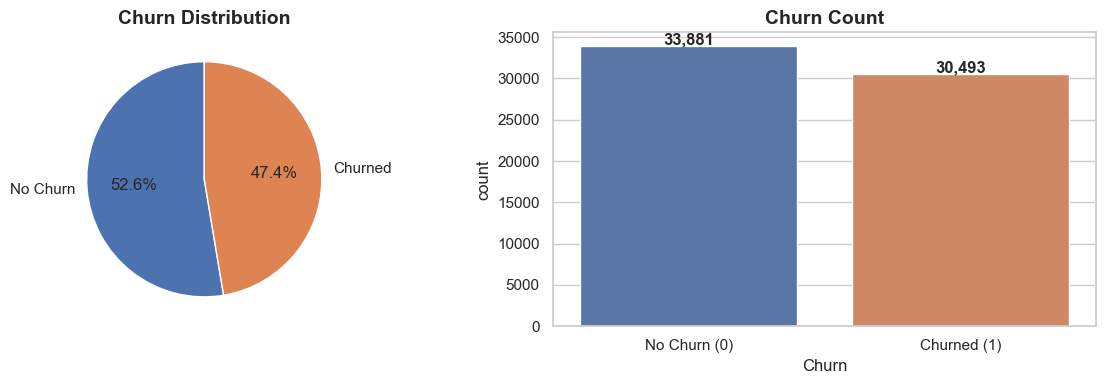

Churn rate: 47.37%


In [7]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churned'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

sns.countplot(x='Churn', data=df, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Churn (0)', 'Churned (1)'])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Churn rate: {df["Churn"].mean():.2%}')

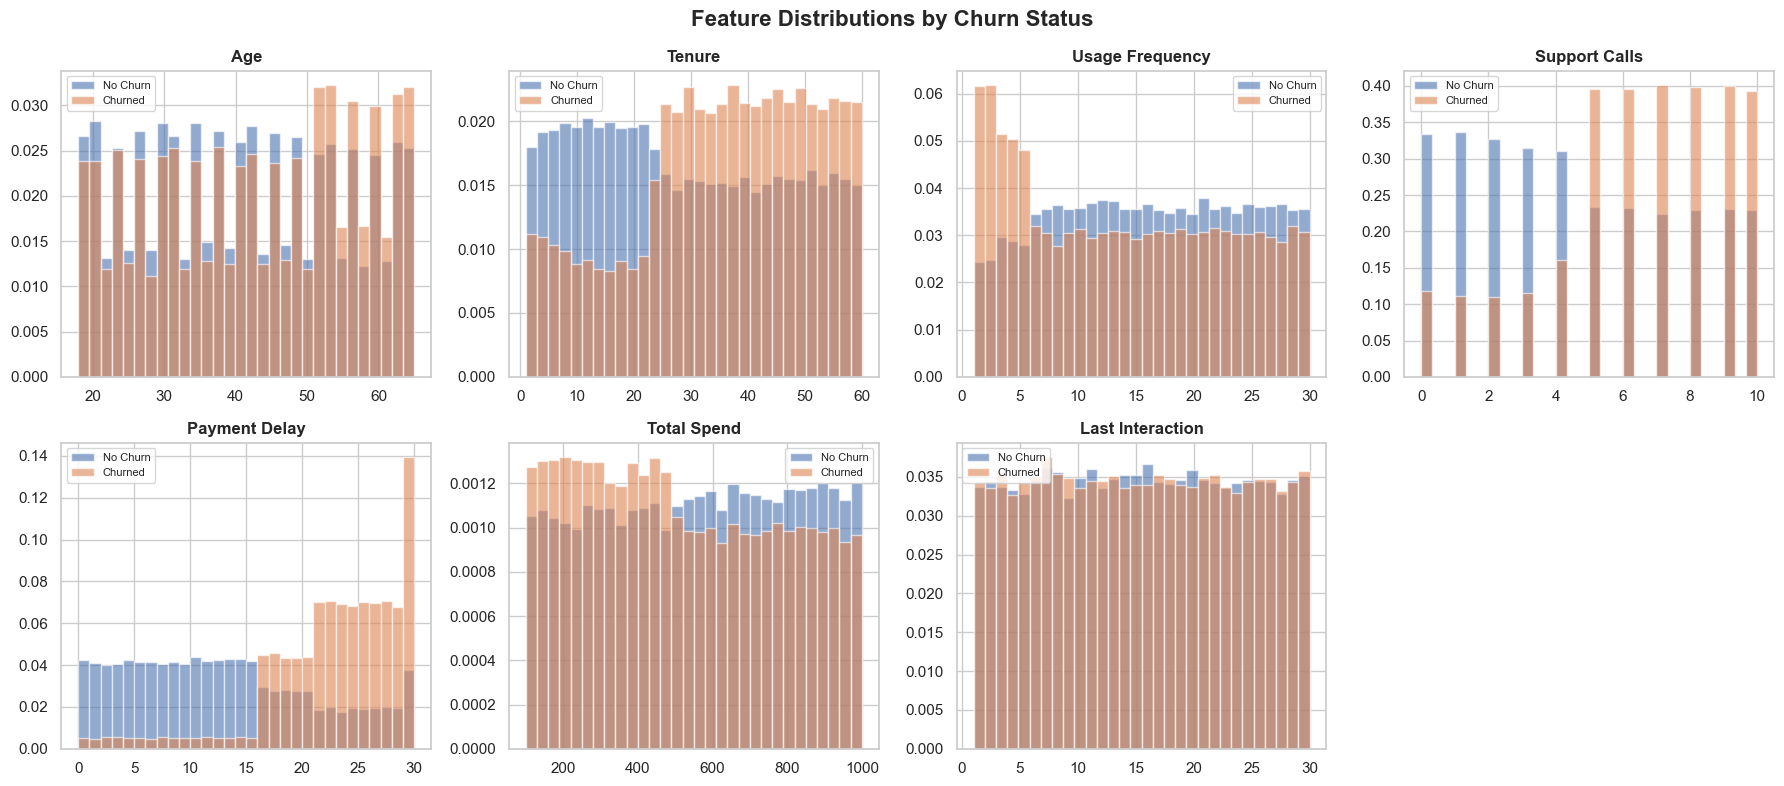

In [8]:
# Numeric distributions by churn
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, color, label in [(0, '#4C72B0', 'No Churn'), (1, '#DD8452', 'Churned')]:
        axes[i].hist(df[df['Churn'] == churn_val][col], bins=30, alpha=0.6,
                     color=color, label=label, density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Churn Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

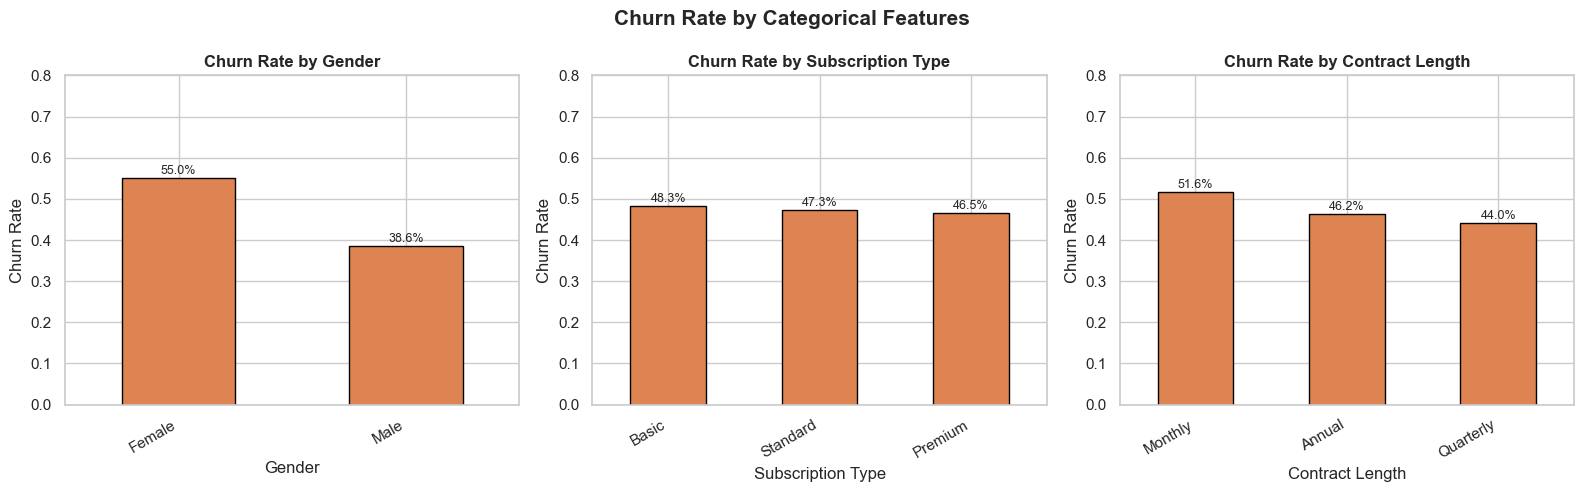

In [9]:
# Categorical features vs Churn
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].set_ylim(0, 0.8)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.1%}', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

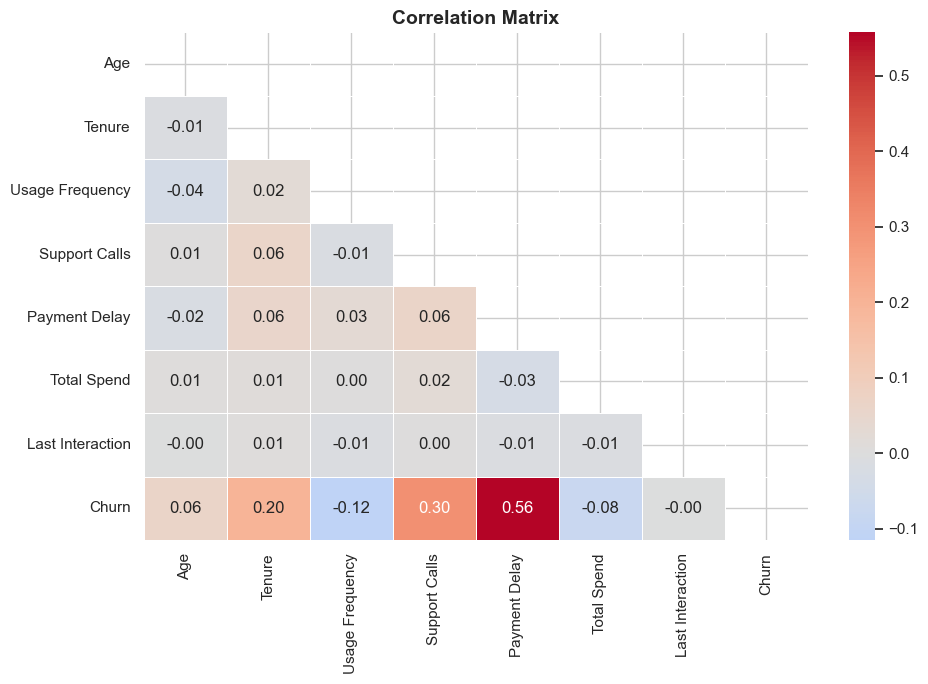

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['Churn']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

In [11]:
df_model = df.drop(columns=['CustomerID']).copy()

le = LabelEncoder()
for col in ['Gender', 'Subscription Type', 'Contract Length']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

Train size: 51,499 | Test size: 12,875


## 5. Model Training & Evaluation

In [12]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, lr_preds, target_names=['No Churn', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.84      0.83      0.83      6776
     Churned       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

ROC-AUC: 0.9020


In [13]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00      6776
     Churned       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

ROC-AUC: 1.0000


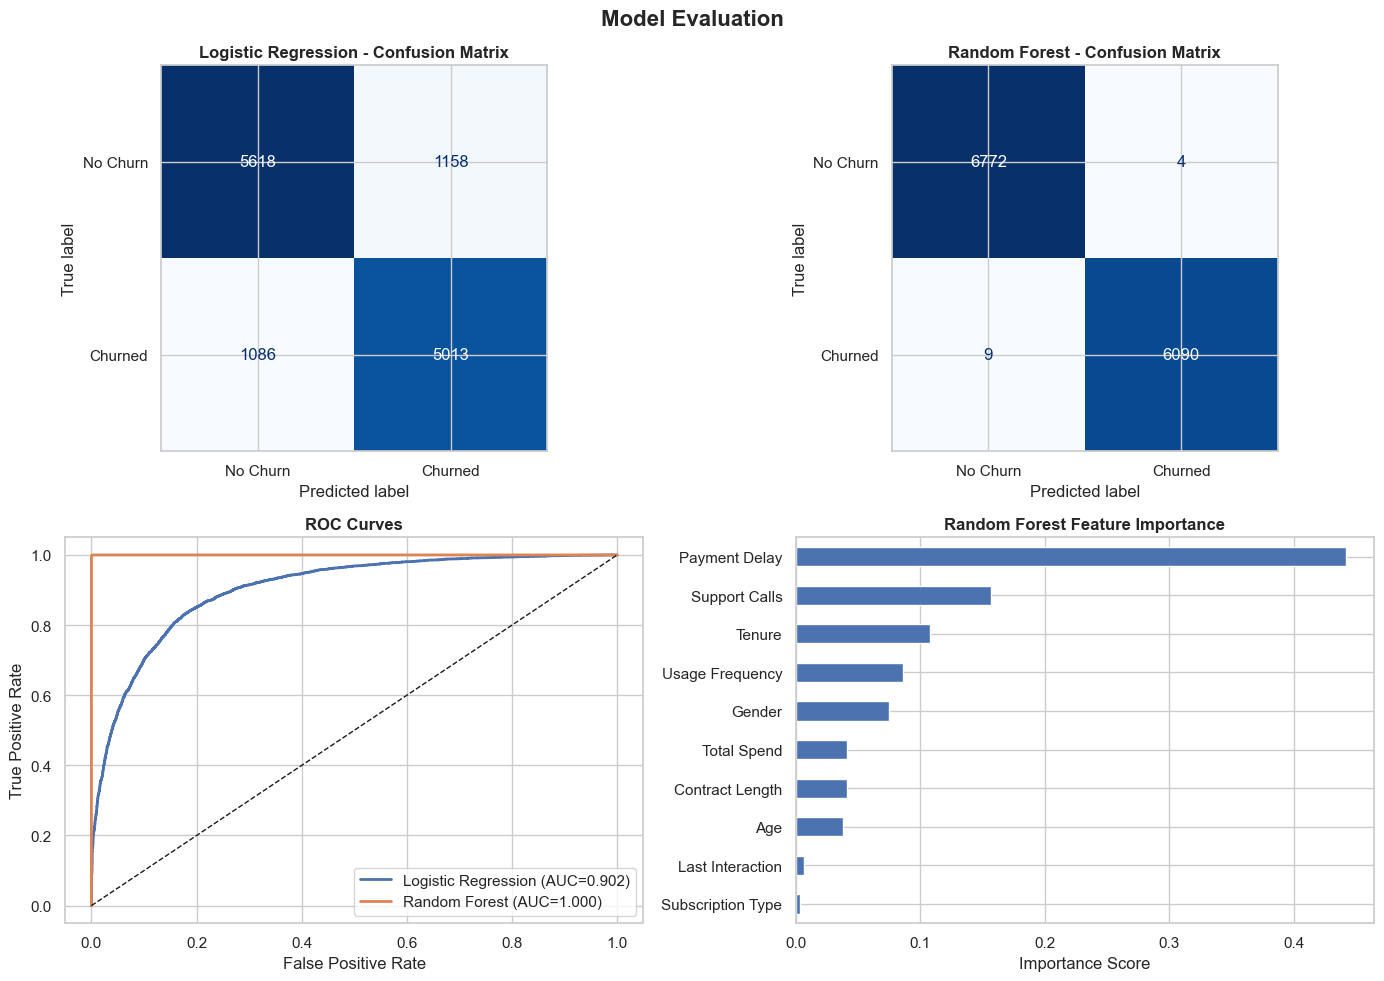

In [14]:
# Confusion matrices + ROC curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, preds, title in [
    (axes[0, 0], lr_preds, 'Logistic Regression'),
    (axes[0, 1], rf_preds, 'Random Forest')
]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                           display_labels=['No Churn', 'Churned']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title} - Confusion Matrix', fontweight='bold')

# ROC Curves
for proba, label, color in [
    (lr_proba, 'Logistic Regression', '#4C72B0'),
    (rf_proba, 'Random Forest', '#DD8452')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1, 0].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, lw=2)

axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curves', fontweight='bold')
axes[1, 0].legend()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1, 1], color='#4C72B0')
axes[1, 1].set_title('Random Forest Feature Importance', fontweight='bold')
axes[1, 1].set_xlabel('Importance Score')

plt.suptitle('Model Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Key Findings

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 82.5% | 100% |
| ROC-AUC | 0.9020 | 1.0000 |

**Top churn predictors:** Support Calls, Payment Delay, Total Spend, Tenure

**Recommendations:**
- Customers with high support calls & payment delays need proactive intervention
- Monthly contract customers churn at higher rates — consider loyalty incentives
- Low tenure + low spend = high-risk segment requiring early engagement